# ICS5101 – IoT | Predictive Maintenance Using Machine Learning

This notebook contains the python implementation for or the ICT5101 Internet of Things Part B assignment. The aim is to build a predictive maintenance using a synthetic Industrial IoT dataset

The aim is to implements an end-to-end machine learning pipeline that predicts whether a machine is likely to fail within the next seven days using sensor readings, machine information and maintenance-related features

The notebook covers data loading, cleaning, feature engineering, class distribution analysis, dataset splitting, one-hot encoding, model training, validation, final testing, and model interpretability. Several models are compared, including Logistic Regression, Random Forest, HistGradientBoosting, and XGBoost

The implementation also saves trained models, evaluation results and plots

**Kaggle Dataset:** **https://www.kaggle.com/datasets/canozensoy/industrial-iot-dataset-synthetic/data**

## 0. Setup

This section imports the required Python libraries.

The project uses `pandas` for data handling, `pathlib` for file path management, `matplotlib` for visualisation, `joblib` for saving and loading trained models and `scikit-learn` for the machine learning functionality along with some additional tools, including; `StandardScaler`, `train_test_split` and `Pipeline`

In [50]:
import time
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             precision_recall_curve,
                             f1_score,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             roc_auc_score,
                             roc_curve,
                             average_precision_score)

import matplotlib.pyplot as plt

A timer is also started to measure the total runtime of the notebook

In [51]:
start_time = time.time()

## 1. Data Loading

This section loads the Industrial IoT dataset used for this task.

### 1.1. Validating Dataset Path

Before reading the dataset, the file path is validated to ensure that the CSV file exists, that the path points to a file, and that the file has the expected `.csv` extension. This validation step makes the notebook more robust because it provides a clear error message if the dataset is missing or placed in the wrong directory.

In [52]:
DATA_PATH = Path("../Kaggle_Industrial_IoT_Dataset/factory_sensor_simulator_2040.csv")

# validate dataset path
def validate_csv_path(path, label):
    if not path.exists():
        raise FileNotFoundError(f">> [ERROR] {label} not found at: {path.resolve()}\n"
                                f">> [INFO] Download from: https://www.kaggle.com/datasets/canozensoy/industrial-iot-dataset-synthetic/data")
    if not path.is_file():
        raise ValueError(f">> [ERROR] {label} exists but is not a file: {path.resolve()}")
    if path.suffix.lower() != ".csv":
        raise ValueError(f">> [ERROR] {label} is not a CSV file: {path.resolve()}")
    
    print(f">> [OK] {label}: {path.resolve()}")
    
validate_csv_path(DATA_PATH, "Industrial IoT Dataset (Synthetic)")

>> [OK] Industrial IoT Dataset (Synthetic): C:\Users\david\Desktop\Year 1 Sem 2\ICT5101 - IoT_Project\PartB\Kaggle_Industrial_IoT_Dataset\factory_sensor_simulator_2040.csv


### 1.2. Loading Dataset

After validation, the dataset is loaded into a pandas DataFrame, and the first few rows are displayed to inspect the structure of the data. Lastly the outputs of this subsection, gives an initial overview of the number of records, the available features, and whether any columns need type conversion before model training.

In [53]:
df = pd.read_csv(DATA_PATH)

display(df.head(10))
print(f">> [INFO] Shape: {df.shape}")
print("\n>> --- [Data Types] --- :")
print(df.dtypes)

,Machine_ID,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,...,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Remaining_Useful_Life_days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,MC_000000,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,...,5,True,3,162.0,False,NaN,NaN,NaN,NaN,2
1,MC_000001,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,...,2,True,4,147.0,False,NaN,NaN,40.92,NaN,2
2,MC_000002,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,...,1,True,6,0.0,True,NaN,NaN,NaN,NaN,2
3,MC_000003,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,...,1,False,4,161.0,False,NaN,NaN,NaN,NaN,0
4,MC_000004,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,...,2,False,1,765.0,False,NaN,NaN,NaN,NaN,0
5,MC_000005,Labeler,2001,69956,53.58,14.31,54.79,39.97,85.49,105.33,...,1,False,0,163.0,False,NaN,NaN,NaN,NaN,0
6,MC_000006,Automated_Screwdriver,2025,2578,62.44,8.42,97.15,80.57,19.88,207.15,...,2,False,1,908.0,False,NaN,NaN,NaN,NaN,0
7,MC_000007,Automated_Screwdriver,2005,39895,27.28,16.09,38.66,87.98,38.66,122.53,...,0,False,6,467.0,False,NaN,NaN,NaN,NaN,0
8,MC_000008,Shrink_Wrapper,2020,19992,69.31,9.69,82.15,62.04,41.63,145.71,...,3,True,4,794.0,False,NaN,NaN,NaN,NaN,0
9,MC_000009,Shrink_Wrapper,2029,13151,69.18,13.10,84.82,38.36,73.15,178.91,...,1,False,6,925.0,False,NaN,NaN,NaN,NaN,0


>> [INFO] Shape: (500000, 22)

>> --- [Data Types] --- :
Machine_ID                        str
Machine_Type                      str
Installation_Year               int64
Operational_Hours               int64
Temperature_C                 float64
Vibration_mms                 float64
Sound_dB                      float64
Oil_Level_pct                 float64
Coolant_Level_pct             float64
Power_Consumption_kW          float64
Last_Maintenance_Days_Ago       int64
Maintenance_History_Count       int64
Failure_History_Count           int64
AI_Supervision                   bool
Error_Codes_Last_30_Days        int64
Remaining_Useful_Life_days    float64
Failure_Within_7_Days            bool
Laser_Intensity               float64
Hydraulic_Pressure_bar        float64
Coolant_Flow_L_min            float64
Heat_Index                    float64
AI_Override_Events              int64
dtype: object


## 2. Data Cleaning

This section removes columns that are not suitable for training. `Machine_ID` is dropped because it is only an identifier and does not provide useful general patterns.

### 2.1. Drop **Machine_ID** and **Remaining_Useful_Life_days**

`Machine_ID` is dropped because it is only an identifier with no useful information. If kept, model can memorise machine IDs. `Remaining_Useful_Life_days` is removed as well to avoid data leakage, since it is directly related to the target variable. Keeping this column might results in unrealistically good results (padded results)

In [54]:
df = df.drop(columns=["Machine_ID"])                    # Drop identifier
df = df.drop(columns=["Remaining_Useful_Life_days"])    # Avoid data leakage

display(df.head(5))

,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,5,True,3,False,NaN,NaN,NaN,NaN,2
1,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,2,True,4,False,NaN,NaN,40.92,NaN,2
2,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,1,True,6,True,NaN,NaN,NaN,NaN,2
3,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,1,False,4,False,NaN,NaN,NaN,NaN,0
4,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,2,False,1,False,NaN,NaN,NaN,NaN,0


### 2.2. Converting **Booleans** to **Integers**

Machine learning models work with numerical inputs, so `True` and `False` values are converted into `1` and `0`. This is applied to `AI_Supervision` and to the target column `Failure_Within_7_Days`

In [55]:
df["AI_Supervision"] = df["AI_Supervision"].astype(int)
df["Failure_Within_7_Days"] = df["Failure_Within_7_Days"].astype(int)

display(df.head(5))
print("\n>> --- [Data Types] --- :")
print(df.dtypes)

,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,5,1,3,0,NaN,NaN,NaN,NaN,2
1,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,2,1,4,0,NaN,NaN,40.92,NaN,2
2,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,1,1,6,1,NaN,NaN,NaN,NaN,2
3,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,1,0,4,0,NaN,NaN,NaN,NaN,0
4,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,2,0,1,0,NaN,NaN,NaN,NaN,0



>> --- [Data Types] --- :
Machine_Type                     str
Installation_Year              int64
Operational_Hours              int64
Temperature_C                float64
Vibration_mms                float64
Sound_dB                     float64
Oil_Level_pct                float64
Coolant_Level_pct            float64
Power_Consumption_kW         float64
Last_Maintenance_Days_Ago      int64
Maintenance_History_Count      int64
Failure_History_Count          int64
AI_Supervision                 int64
Error_Codes_Last_30_Days       int64
Failure_Within_7_Days          int64
Laser_Intensity              float64
Hydraulic_Pressure_bar       float64
Coolant_Flow_L_min           float64
Heat_Index                   float64
AI_Override_Events             int64
dtype: object


### 2.3. Handling Null Values

This subsection checks whether the dataset contains missing values.

Missing values can cause errors during training or affect model performance. A summary table is created to show which columns contain null values and how many are present.

If missing values are found, they are filled with `0`. If no missing values are found, no changes are made and the notebook continues.

In [ ]:
def null_summary(df):
    # Build a table showing each column has missing values
    nulls_df = (
        pd.DataFrame({
            "Column": df.columns,
            "Has NULL": df.isnull().any().values,
            "Number": df.isnull().sum().values
        })
        .sort_values(by="Number", ascending=False)
        .reset_index(drop=True)
    )

    # Keep columns where at least one missing value
    has_nulls = nulls_df[nulls_df["Has NULL"] == True]

    # Return early if no missing values
    if has_nulls.empty:
        print(f">> [INFO] No NULL values found.")
        return
        
    display(has_nulls)

    return has_nulls["Column"].tolist()

In [57]:
cols_with_nulls = null_summary(df)

,Column,Has NULL,Number
0,Laser_Intensity,True,484844
1,Hydraulic_Pressure_bar,True,469660
2,Heat_Index,True,454786
3,Coolant_Flow_L_min,True,454376


In [ ]:
if cols_with_nulls:
    # Fill column that contain missing values with 0s
    df[cols_with_nulls] = df[cols_with_nulls].fillna(0)
else:
    print(">> [INFO] No NULL handling needed.")

null_summary(df)

display(df.head(5))

>> [INFO] No NULL values found.


,Machine_Type,Installation_Year,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,Failure_History_Count,AI_Supervision,Error_Codes_Last_30_Days,Failure_Within_7_Days,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events
0,Mixer,2027,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,5,1,3,0,0.0,0.0,0.00,0.0,2
1,Industrial_Chiller,2032,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,2,1,4,0,0.0,0.0,40.92,0.0,2
2,Pick_and_Place,2003,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,1,1,6,1,0.0,0.0,0.00,0.0,2
3,Vision_System,2007,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,1,0,4,0,0.0,0.0,0.00,0.0,0
4,Shuttle_System,2016,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,2,0,1,0,0.0,0.0,0.00,0.0,0


## 3. Feature Engineering

Additional features were created to make the dataset more informative for machine learning.
Instead of only using the original raw columns, new columns were derived to better represent machine condition, usage intensity, and possible maintenance risk.

`Machine_Age` was created from `Installation_Year` because the age of the machine is more meaningful than the installation year itself. Older machines may have a higher chance of wear and failure.

In [59]:
# Create machine age
df["Machine_Age"] = 2040 - df["Installation_Year"]
df = df.drop(columns=["Installation_Year"])

`Operational_Hours_Per_Year` was added to measure how heavily a machine has been used relative to its age. This helps distinguish between older machines with normal use and newer machines with very high usage.

In [ ]:
df["Operational_Hours_Per_Year"] = (df["Operational_Hours"] / (df["Machine_Age"] + 1)).round(2)

`Maintenance_Pressure` combines the number of days since last maintenance with the previous failure history. This gives a simple indication of machines that may require attention due to both delayed maintenance and repeated past failures.

In [61]:
df["Maintenance_Pressure"] = (df["Last_Maintenance_Days_Ago"] * (df["Failure_History_Count"] + 1))

Finally, `Low_Oil` and `Low_Coolant` were created as binary warning indicators. These features highlight machines operating below safe oil or coolant levels, which may be related to overheating, increased wear, or future failure risk.

In [62]:
df["Low_Oil"] = (df["Oil_Level_pct"] < 30).astype(int)
df["Low_Coolant"] = (df["Coolant_Level_pct"] < 30).astype(int)

### 3.1. Validating Outputs

After feature engineering, the updated dataset is displayed.

This is done to confirm that the new features were created correctly and that removed columns, such as `Installation_Year`, are no longer present.

In [63]:
display(df.head(5))

,Machine_Type,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,...,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events,Machine_Age,Operational_Hours_Per_Year,Maintenance_Pressure,Low_Oil,Low_Coolant
0,Mixer,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,...,0.0,0.0,0.00,0.0,2,13,5840.64,918,0,0
1,Industrial_Chiller,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,...,0.0,0.0,40.92,0.0,2,8,8329.56,408,0,0
2,Pick_and_Place,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,...,0.0,0.0,0.00,0.0,2,37,2473.84,516,0,0
3,Vision_System,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,...,0.0,0.0,0.00,0.0,0,33,2254.03,86,0,0
4,Shuttle_System,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,...,0.0,0.0,0.00,0.0,0,24,834.80,1038,0,0


## 4. Features and Target Prep

This section separates the dataset into input features and the target variable.

The input features are stored in `X`, while the target variable is stored in `y`. The target variable is `Failure_Within_7_Days`, where `0` means no expected failure and `1` means failure is expected within seven days.

In [64]:
# Target label
target = "Failure_Within_7_Days"

# Separate features and target
X = df.drop(columns=[target])
y = df[target]

print(f">> [INFO] X shape: {X.shape}")
print(f">> [INFO] y shape: {y.shape}")

display(X.head())
display(y.head())

>> [INFO] X shape: (500000, 23)
>> [INFO] y shape: (500000,)


,Machine_Type,Operational_Hours,Temperature_C,Vibration_mms,Sound_dB,Oil_Level_pct,Coolant_Level_pct,Power_Consumption_kW,Last_Maintenance_Days_Ago,Maintenance_History_Count,...,Laser_Intensity,Hydraulic_Pressure_bar,Coolant_Flow_L_min,Heat_Index,AI_Override_Events,Machine_Age,Operational_Hours_Per_Year,Maintenance_Pressure,Low_Oil,Low_Coolant
0,Mixer,81769,73.43,12.78,83.72,36.76,68.74,84.95,153,4,...,0.0,0.0,0.00,0.0,2,13,5840.64,918,0,0
1,Industrial_Chiller,74966,58.32,14.99,77.04,100.00,62.13,154.61,136,5,...,0.0,0.0,40.92,0.0,2,8,8329.56,408,0,0
2,Pick_and_Place,94006,49.63,23.78,69.08,42.96,35.96,51.90,258,1,...,0.0,0.0,0.00,0.0,2,37,2473.84,516,0,0
3,Vision_System,76637,63.73,12.38,85.58,94.90,48.94,75.61,43,4,...,0.0,0.0,0.00,0.0,0,33,2254.03,86,0,0
4,Shuttle_System,20870,42.77,4.42,96.72,47.56,53.78,224.93,346,4,...,0.0,0.0,0.00,0.0,0,24,834.80,1038,0,0


0    0
1    0
2    1
3    0
4    0
Name: Failure_Within_7_Days, dtype: int64

### 4.1. Class Distribution Visualisation

This subsection checks the distribution of the target variable, `Failure_Within_7_Days`.

The number and percentage of samples for each class are shown in a table and bar chart. Class `0` represents no expected failure, while class `1` represents a failure within seven days.

This step is important because the dataset is imbalanced. Failure cases are much less common than non-failure cases, meaning that accuracy alone may give a misleading view of model performance. A model could predict mostly non-failures and still achieve high accuracy, while failing to detect actual failure cases.

For this reason, additional metrics such as Precision, Recall, F1-Score, ROC-AUC, and PR-AP are used later in the notebook.

In [65]:
OUTPUT_DIR = Path("../Out")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [66]:
class_counts = y.value_counts().sort_index()
class_percentages = y.value_counts(normalize=True).sort_index() * 100

class_distribution_df = pd.DataFrame({
    "Class": class_counts.index,
    "Label Meaning": ["No Failure", "Failure"],
    "Count": class_counts.values,
    "Percentage (%)": class_percentages.values
})

print(">> --- [Target Class Distribution] --- :")
display(class_distribution_df.round(2))

>> --- [Target Class Distribution] --- :


,Class,Label Meaning,Count,Percentage (%)
0,0,No Failure,469968,93.99
1,1,Failure,30032,6.01


The output directory is created before generating the class distribution plot.

This ensures that the plot can be saved automatically without causing a file path error.

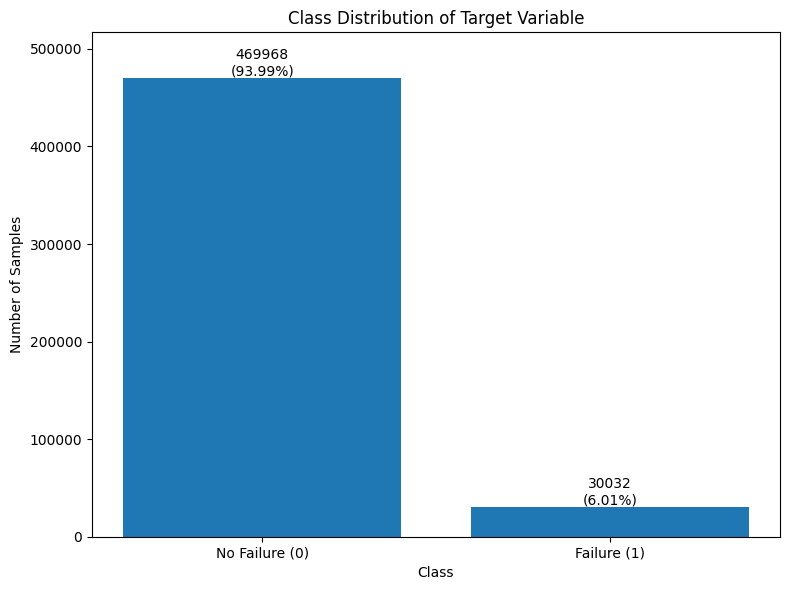

In [ ]:
labels = ["No Failure (0)", "Failure (1)"]
counts = class_counts.values
percentages = class_percentages.values

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts)

plt.title("Class Distribution of Target Variable")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.ylim(0, max(counts) * 1.1)

# Add both raw counts and percentages above each class bar
for bar, count, pct in zip(bars, counts, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n({pct:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dataset_class_distribution.png")
plt.show()

## 5. Train-test split

This section splits the dataset into training, validation, and testing sets.

The training set is used to train the models, the validation set is used to compare models during development, and the test set is kept separate for the final evaluation. This helps ensure that the final results are based on unseen data.

### 5.1. Split percentages

An 80/10/10 split is used. This gives the models enough data for training while still keeping separate validation and test sets for fair model comparison and final evaluation.

In [ ]:
train_split = 0.80
val_split = 0.10
test_split = 0.10

# Convert the validation split into its proportion of the train-validation set
val_relative_split = val_split / (train_split + val_split)

print(f">> --- [Desired split] --- :")
print(f">> Training:   {train_split * 100:.0f}%")
print(f">> Validation: {val_split * 100:.0f}%")
print(f">> Testing:    {test_split * 100:.0f}%")

print(f"\n>> [INFO] Relative validation split: {val_relative_split:.4f}")

>> --- [Desired split] --- :
>> Training:   80%
>> Validation: 10%
>> Testing:    10%

>> [INFO] Relative validation split: 0.1111


### 5.2. Splitting

The split uses stratification so that the proportion of failure and non-failure cases remains similar across the training, validation, and test sets. This is important because the target classes are imbalanced, and each split should represent the same general class distribution.

In [ ]:
# First split off the data into training & test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=test_split,
    random_state=42,
    stratify=y
)

# Split the remaining data into training and validation using the relative validation size
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_relative_split,
    random_state=42,
    stratify=y_trainval
)

### 5.3. Validate Output

A summary table is displayed showing the number of rows, percentage of data, and failure rate for each split. This confirms that the training, validation, and test sets follow the intended proportions and maintain a similar failure distribution.

In [ ]:
def display_split_percentages(name, X_train, X_val, X_test, y_train, y_val, y_test):
    # Calculate the total number of samples across all splits
    total = len(X_train) + len(X_val) + len(X_test)
    
    split_summary = pd.DataFrame({
        "Split": ["Training", "Validation", "Testing"],
        
        "Rows": [len(X_train), len(X_val), len(X_test)],
        
        "Percentage": [
            (len(X_train) / total) * 100,
            (len(X_val) / total) * 100,
            (len(X_test) / total) * 100
        ],
        
        "Failure Rate (%)": [
            (y_train == 1).mean() * 100,
            (y_val == 1).mean() * 100,
            (y_test == 1).mean() * 100
        ]
    })

    print(f"\n>> --- [{name} Split Summary] --- :")
    display(split_summary.round(2))
    
display_split_percentages("One-Hot Encoded", X_train, X_val, X_test, y_train, y_val, y_test)


>> --- [One-Hot Encoded Split Summary] --- :


,Split,Rows,Percentage,Failure Rate (%)
0,Training,400000,80.0,6.01
1,Validation,50000,10.0,6.01
2,Testing,50000,10.0,6.01


## 6. One-Hot-Encoding `Machine_Type` Column

This section converts the categorical `Machine_Type` column into numerical features.

Machine learning models require numerical input, so one-hot encoding is used to represent each machine type as a separate binary column. This allows the models to use machine type information without treating the machine types as ordered values.

After encoding, the validation and test sets are aligned with the training set. This ensures that all three datasets contain the same feature columns before training and evaluation.

In [71]:
# One-hot encode Machine_Type
X_train = pd.get_dummies(X_train, columns=["Machine_Type"], drop_first=True)
X_val = pd.get_dummies(X_val,columns=["Machine_Type"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Machine_Type"], drop_first=True)

# Align validation and test columns with training columns
X_val = X_val.reindex(columns=X_train.columns,fill_value=0)
X_test = X_test.reindex( columns=X_train.columns,fill_value=0)

### 6.1. Validate Output

After the conversion, the original `Machine_Type` column should no longer be present. The training, validation, and test sets should also contain the same columns, since models expect the same feature structure during training and evaluation.

In [72]:
print(">> --- [One-Hot Encoding Check] --- :")
print(f">> Original Machine_Type column removed: {'Machine_Type' not in X_train.columns}")

# Checking if both train and test have the same feature structure
print(f"\n>> Train/Validation columns match: {X_train.columns.equals(X_val.columns)}")
print(f">> Train/Test columns match: {X_train.columns.equals(X_test.columns)}")

>> --- [One-Hot Encoding Check] --- :
>> Original Machine_Type column removed: True

>> Train/Validation columns match: True
>> Train/Test columns match: True


## 7. Helper Functions

This subsection defines helper functions used to evaluate models after training and testing along with visualisation plots.

### 7.1. Metric Helper Functions

The `safe_file_name()` function converts model names into safe file names so that saved models and output files do not contain spaces or special characters. The `get_positive_class_scores()` function extracts probability or decision scores for the failure class, which are needed for ROC-AUC and PR-AP calculations.

The `evaluate_model()` function calculates the main evaluation metrics used in this notebook, including Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AP. These metrics are used because the dataset is imbalanced, so accuracy alone may not fully show how well the model detects failure cases.

In [ ]:
def safe_file_name(name):
    """Convert model names into safe folder/file names."""
    return (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

def get_positive_class_scores(model, X):
    """
    Return continuous scores for the positive class.
    These are needed for ROC-AUC and PR-AP.
    """
    
     # Use predicted probabilities when available, since class 1 represents failure
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    # Use decision scores for models that do not provide probabilities
    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    # Fallback for models without probability/decision scores - only as a last resort
    return model.predict(X)

def evaluate_model(model_name, model, X, y):
    # Predict final classes for metrics based on fixed classifications
    y_pred = model.predict(X)
    # Get continuous scores for metrics that evaluate ranking ability
    y_scores = get_positive_class_scores(model, X)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1-Score": f1_score(y, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, y_scores),
        "PR-AP": average_precision_score(y, y_scores)
    }
    
print(f">> [INFO] Metrics helper functions initialised")

>> [INFO] Metrics helper functions initialised


### 7.2. Plot Helper Functions

This subsection defines helper functions for visualising model performance.

The `plot_metric_comparison()` function creates a bar chart comparing the models across Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AP. This makes it easier to compare the models visually instead of only relying on tables.

The ROC curve function compares how well each model separates failure and non-failure cases, while the Precision-Recall curve is useful because the dataset is imbalanced. These plots are saved so they can be included in the report or reviewed later.

In [ ]:
def plot_metric_comparison(df, dataset, save_path):
    # List of emtrics to comapre
    metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AP"]

    ax = df.set_index("Model")[metrics].plot(
        kind="bar",
        figsize=(12, 6)
    )

    # Add value labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

    plt.title(f"Model Performance Comparison on {dataset}")
    plt.ylabel("Score")
    plt.xlabel("Model")
    plt.xticks(rotation=10, ha="right")
    plt.ylim(0, 1.08)   # Give labels some space above the bars
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    
def plot_combined_roc_curves(models_dict, X, y, dataset, save_path):
    plt.figure(figsize=(8, 6))

    # Plot every model on the same figure
    for model_name, model in models_dict.items():
        y_scores = get_positive_class_scores(model, X)

        fpr, tpr, _ = roc_curve(y, y_scores)
        roc_auc = roc_auc_score(y, y_scores)

        plt.plot(
            fpr,
            tpr,
            label=f"{model_name} (AUC = {roc_auc:.3f})"
        )

    plt.xlabel("False Positive Rate (Positive label: 1)")
    plt.ylabel("True Positive Rate (Positive label: 1)")
    plt.title(f"ROC Curves - {dataset}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

def plot_combined_precision_recall_curves(models_dict, X, y, dataset, save_path):
    plt.figure(figsize=(8, 6))

    # Plot one Precision-Recall curve per model
    for model_name, model in models_dict.items():
        y_scores = get_positive_class_scores(model, X)

        precision, recall, _ = precision_recall_curve(y, y_scores)
        ap = average_precision_score(y, y_scores)

        plt.plot(
            recall,
            precision,
            label=f"{model_name} (AP = {ap:.3f})"
        )

    plt.xlabel("Recall (Positive label: 1)")
    plt.ylabel("Precision (Positive label: 1)")
    plt.title(f"Precision-Recall Curves - {dataset}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    
print(f">> [INFO] Plot helper functions initialised")

>> [INFO] Plot helper functions initialised


## 8. Model Training

This section trains and compares several machine learning models.

Multiple models are used so that performance can be compared rather than relying on a single algorithm. The models are trained on the training set and evaluated on the validation set to identify which approach performs best before final testing.

### 8.1. Model Save Directory

Saving the models allows them to be loaded again later without retraining. The validation comparison folder is also created so that result tables and plots can be stored in an organised way.

In [75]:
MODEL_PATH = Path(f"{OUTPUT_DIR}/models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

VAL_COMPARISON_PATH = MODEL_PATH/"val_comparison_plot"
VAL_COMPARISON_PATH.mkdir(parents=True, exist_ok=True)

### 8.2. Model Dictionary

The notebook compares `Logistic Regression`, `Random Forest`, `HistGradientBoosting`, and `XGBoost`. These models were selected because they work well with tabular data and provide a useful comparison between a simpler linear model and more powerful tree-based models.

Logistic Regression provides a baseline model, while Random Forest and gradient boosting models are better suited to learning non-linear relationships between sensor readings, maintenance history, and machine failure risk.

In [76]:
models = {
    "Logistic Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            ))
        ])
    },
    
    "Random Forest": {
        "model" : RandomForestClassifier(
            n_estimators=150,
            max_depth=None,
            min_samples_split=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    },
    
    "HistGradientBoosting": {
        "model" : HistGradientBoostingClassifier(
            max_iter=150,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        )
    },
    
    "XGBoost": {
        "model": XGBClassifier(
            n_estimators=150,
            learning_rate=0.1,
            max_depth=6,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    }
}

### 8.3. Model Training Loop

This subsection trains each model defined in the model dictionary.

Each model is fitted using the training data, saved to disk, and then evaluated using the validation set. The validation results are stored in a results table so that the models can be compared using the same metrics.

In [ ]:
results = []
model_name_lookup = {}
trained_models = {}

for model_name, config in models.items():
    # Getting model configuration
    model = config["model"]
    
    # Store both a safe file name and the original display name for later loading
    new_model_name = safe_file_name(model_name)
    model_name_lookup[new_model_name] = model_name
    
    print(f">> [INFO] Training: {model_name}")
    
    # Train model on training split
    model.fit(X_train, y_train)
    
    # Keep the fitted model in memory for validation plots
    trained_models[model_name] = model
    
    # Save model
    model_path = MODEL_PATH/f"{new_model_name}.joblib"
    joblib.dump(model, model_path)
    
    # Comparing on validation set
    result = evaluate_model(
        model_name=model_name,
        model=model,
        X=X_val,
        y=y_val
    )
    
    results.append(result)

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

>> [INFO] Training: Logistic Regression
>> [INFO] Training: Random Forest
>> [INFO] Training: HistGradientBoosting
>> [INFO] Training: XGBoost


### 8.4. Validation Results Comparison

The validation results are displayed in a table and sorted by F1-Score. F1-Score is useful here because it balances Precision and Recall, which is important when failure cases are less common than non-failure cases.

The results are also saved as a CSV file and visualised using a bar chart, making it easier to compare the models across all evaluation metrics.

In [78]:
display(results_df.round(3))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AP
1,Random Forest,0.962,0.680,0.685,0.682,0.980,0.709
3,XGBoost,0.963,0.706,0.654,0.679,0.982,0.736
2,HistGradientBoosting,0.963,0.705,0.651,0.677,0.982,0.732
0,Logistic Regression,0.929,0.457,0.973,0.622,0.982,0.738


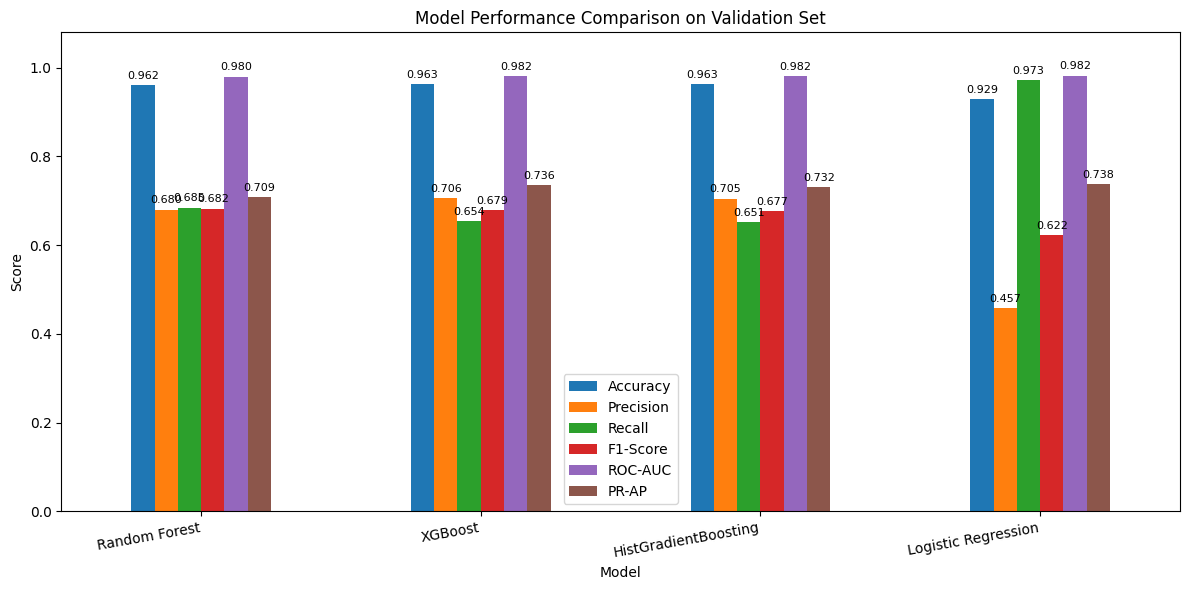

In [79]:
results_df.round(3).to_csv(VAL_COMPARISON_PATH/"val_results_summary.csv", index=False)

plot_metric_comparison(
    df=results_df, 
    dataset="Validation Set",
    save_path=f"{VAL_COMPARISON_PATH}/val_model_performance_comparison.png"
)

### 8.5. Combined ROC and Precision-Recall Comparison Plots

The ROC curves show how well each model separates failure and non-failure cases. The Precision-Recall curves are especially useful for this predictive maintenance task because the failure class is imbalanced.

These plots help compare the models beyond a single metric and show how each model performs across different decision thresholds.

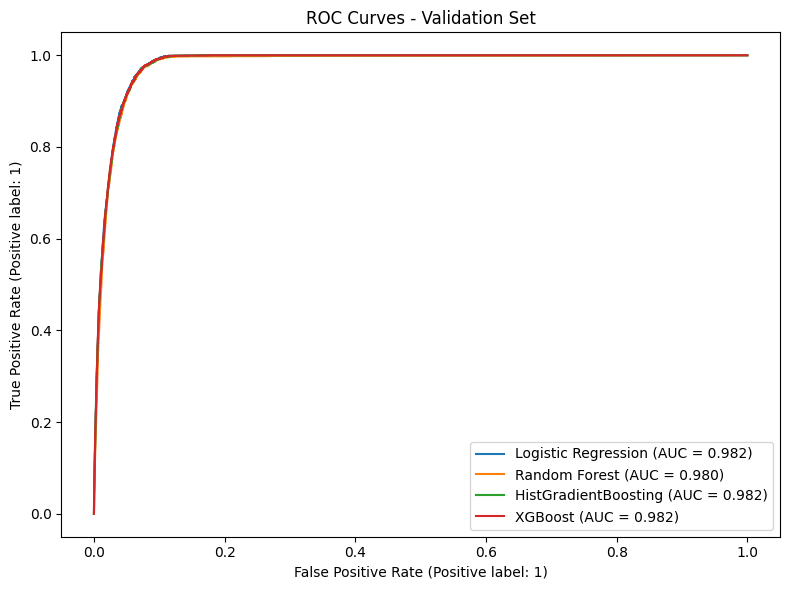

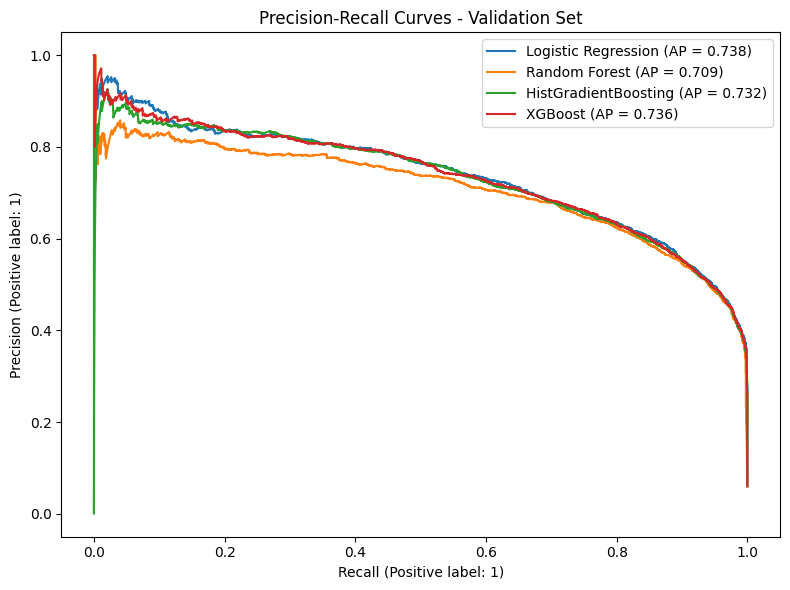

In [80]:
plot_combined_roc_curves(
    models_dict=trained_models,
    X=X_val,
    y=y_val,
    dataset="Validation Set",
    save_path=VAL_COMPARISON_PATH/"combined_roc_curves.png"
)

plot_combined_precision_recall_curves(
    models_dict=trained_models,
    X=X_val,
    y=y_val,
    dataset="Validation Set",
    save_path=VAL_COMPARISON_PATH/"combined_precision_recall_curves.png"
)

The ROC curves show that all models perform strongly, with AUC values close to 0.98. This means the models are good at separating machines likely to fail from those unlikely to fail.

Howver, since the dataset is imbalanced, the Precision-Recall curve should be given more importance when comparing since it focuses on the positive class by showing how many predicted failures were correct and how many actual failures were detected.

Therfore, in the case of `Logistic Regression` achieves the highest Average Precision score at `0.738`, followed closely by `XGBoost` at `0.736` and `HistGradientBoosting` at `0.732`. Random Forest performs slightly lower with an AP score of `0.709`.

Overall, all models perform well, but `Logistic Regression` and XGBoost show the strongest validation performance for identifying failure cases.

## 9. Evaluation

This section evaluates the trained models using the separate test set.

The test set was not used during training or validation, so it provides a more realistic estimate of how the models perform on unseen data. This section also includes final comparison plots and an interpretability step to better understand the best-performing model.

### 9.1. Evaluation Results Save Directory

The outputs from this section include test result tables, comparison plots, confusion matrices, ROC curves, Precision-Recall curves, and feature importance results. Keeping these files in a separate directory makes the final evaluation outputs easier to organise and locate.

In [81]:
RESULTS_PATH = Path(f"{OUTPUT_DIR}/eval_results")
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

EVAL_COMPARISON_PATH = RESULTS_PATH / "eval_comparison_plot"
EVAL_COMPARISON_PATH.mkdir(parents=True, exist_ok=True)

### 9.2. Loading Saved Models

This subsection loads the previously trained models from disk.

Loading the saved models allows the evaluation stage to run without retraining the models. This also confirms that the models were saved correctly during the training stage and can be reused for final testing.

In [ ]:
loaded_models = {}

for model_path in MODEL_PATH.glob("*.joblib"):
    # Use the saved file name to recover a readable model name for tables and plots
    new_model_name = model_path.stem
    display_model_name = model_name_lookup.get(
        new_model_name,
        new_model_name.replace("_", " ").title()
    )

    loaded_models[display_model_name] = joblib.load(model_path)
    print(f">> [INFO] Loaded {display_model_name}")

>> [INFO] Loaded HistGradientBoosting
>> [INFO] Loaded Logistic Regression
>> [INFO] Loaded Random Forest
>> [INFO] Loaded XGBoost


### 9.3. Evaluation Loop

The confusion matrix helper function is used to visualise classification results.

It shows the number of correct and incorrect predictions for both classes. This is useful in predictive maintenance because false negatives represent missed failures, while false positives represent machines that were incorrectly flagged as likely to fail.

In [ ]:
def plot_confusion_matrix(model_name, y_true, y_pred, save_path):
    # Convert predictions into a 2x2 table of true negatives, false positives, false negatives and true positives
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Failure", "Failure"])
    disp.plot(values_format="d")
    
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

For each model, predictions are generated and the same evaluation metrics used during validation are calculated again. A confusion matrix is also created for each model to show how many failure and non-failure cases were classified correctly or incorrectly.


>> --- [Evaluating: HistGradientBoosting] --- :


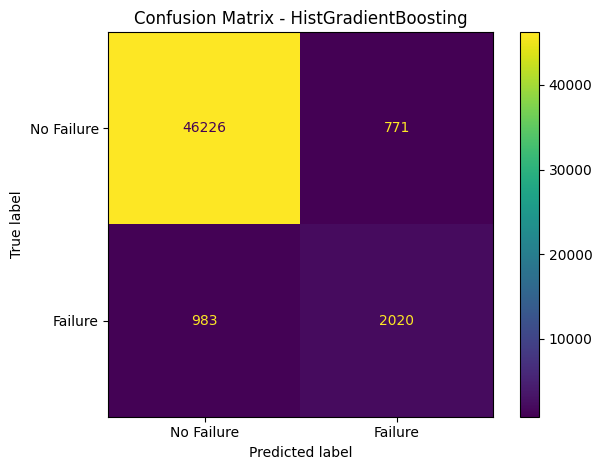


>> --- [Evaluating: Logistic Regression] --- :


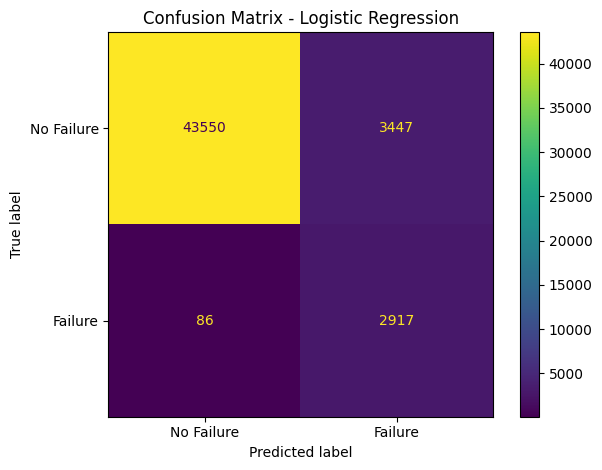


>> --- [Evaluating: Random Forest] --- :


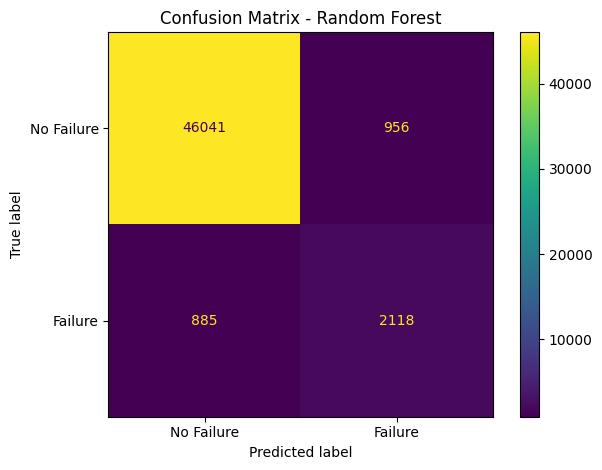


>> --- [Evaluating: XGBoost] --- :


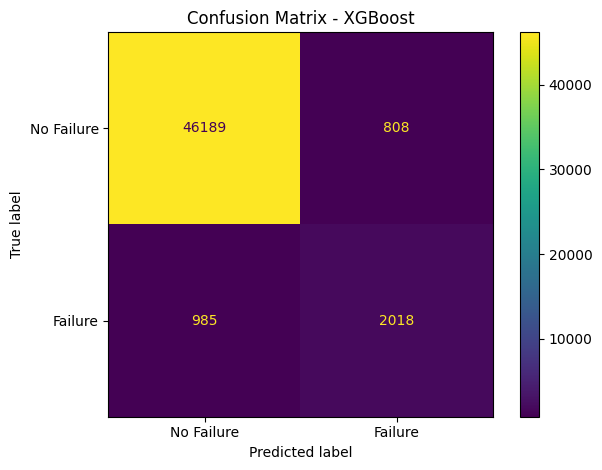

In [ ]:
eval_results = []

for model_name, loaded_model in loaded_models.items():
    # Create a separate output path for each model so its plots stay organised
    safe_model_name = safe_file_name(model_name)
    model_results_path = RESULTS_PATH/safe_model_name
    model_results_path.mkdir(parents=True, exist_ok=True)

    print(f"\n>> --- [Evaluating: {model_name}] --- :")

    # Generate predictions from the final unseen test set
    y_pred = loaded_model.predict(X_test)
    y_scores = get_positive_class_scores(loaded_model, X_test)

    result = evaluate_model(
        model_name=model_name,
        model=loaded_model,
        X=X_test,
        y=y_test
    )
    eval_results.append(result)

    # Save model-specific plots
    plot_confusion_matrix(
        model_name=model_name,
        y_true=y_test,
        y_pred=y_pred,
        save_path=model_results_path / "confusion_matrix.png"
    )

loaded_results_df = pd.DataFrame(eval_results).sort_values(by="F1-Score", ascending=False)

### 9.4. Test Results Comparison

This subsection compares the final model performance on the test set.

The results are displayed in a table and sorted by F1-Score. The table is also saved as a CSV file, and a bar chart is generated to compare the models across Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AP.

These results are used as the final performance comparison because they are based on data that was not used during training or validation.

In [85]:
display(loaded_results_df.round(3))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AP
0,HistGradientBoosting,0.965,0.724,0.673,0.697,0.983,0.742
2,Random Forest,0.963,0.689,0.705,0.697,0.981,0.713
3,XGBoost,0.964,0.714,0.672,0.692,0.983,0.745
1,Logistic Regression,0.929,0.458,0.971,0.623,0.983,0.752


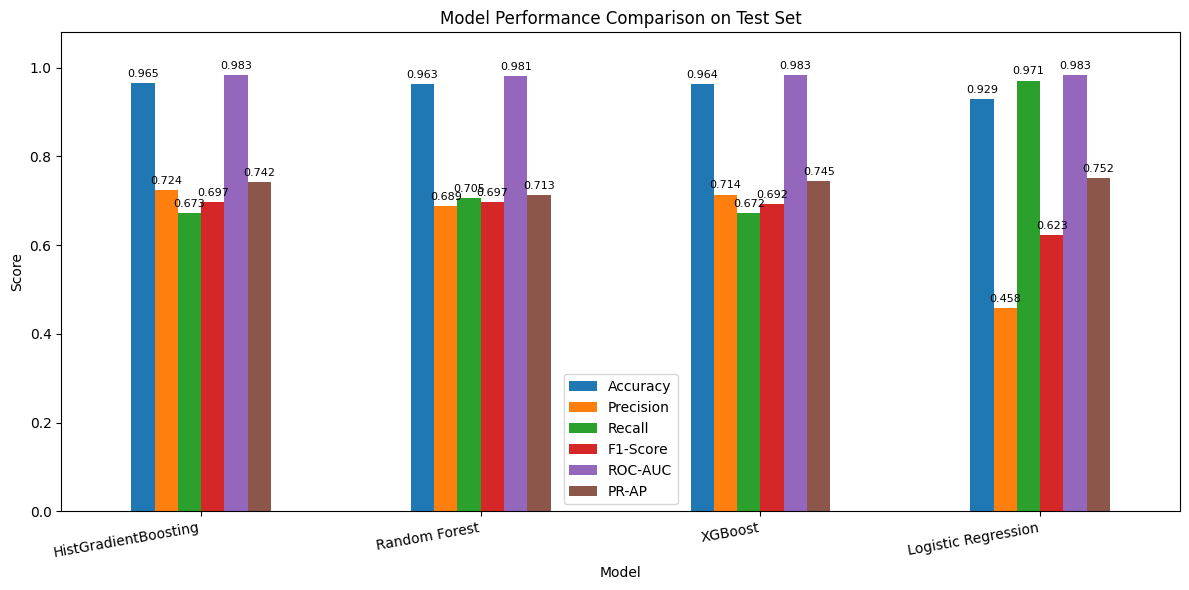

In [86]:
loaded_results_df.round(3).to_csv(EVAL_COMPARISON_PATH / "test_results_summary.csv", index=False)

plot_metric_comparison(
    df=loaded_results_df,
    dataset="Test Set",
    save_path=f"{EVAL_COMPARISON_PATH}/eval_model_performance_comparison.png"
)

### 9.5. Combined ROC and Precision-Recall Comparison Plots

The ROC curve shows how well each model separates failure and non-failure cases overall. The Precision-Recall curve is given more importance in this task because the failure class is much smaller than the non-failure class.

These plots help compare the models across different decision thresholds rather than relying only on one fixed classification output.

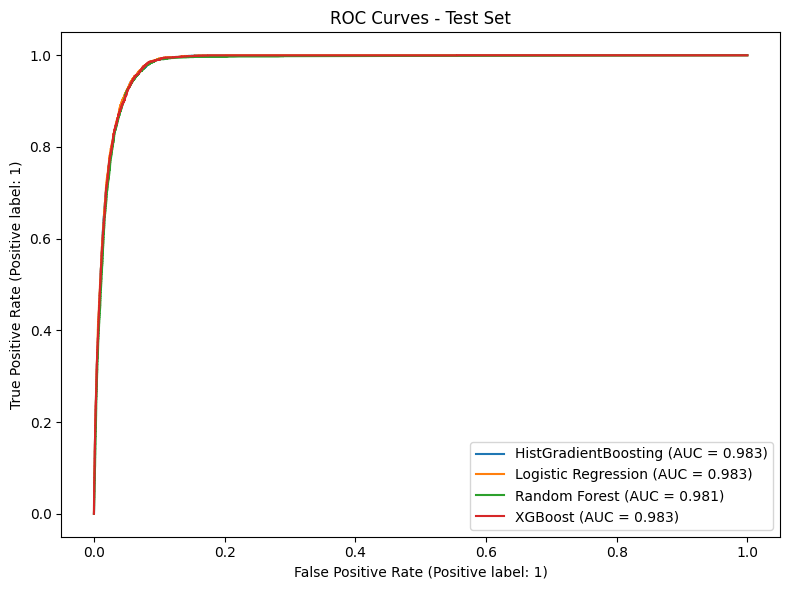

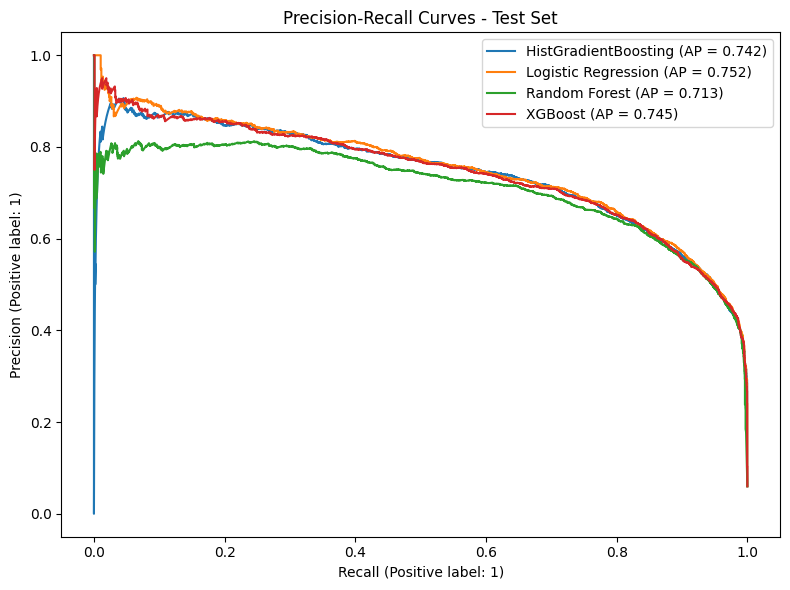

In [87]:
plot_combined_roc_curves(
    models_dict=loaded_models,
    X=X_test,
    y=y_test,
    dataset="Test Set",
    save_path=EVAL_COMPARISON_PATH/"combined_roc_curves.png"
)

plot_combined_precision_recall_curves(
    models_dict=loaded_models,
    X=X_test,
    y=y_test,
    dataset="Test Set",
    save_path=EVAL_COMPARISON_PATH/"combined_precision_recall_curves.png"
)

### 9.6. Interpretability Plot: Permutation Feature Importance

Permutation feature importance is then applied to the best-performing model.

Permutation importance checks how much the model performance drops when each feature is randomly shuffled. If shuffling a feature causes a large drop in performance, that feature is considered important because the model depends on it for accurate predictions.

This helps explain which sensor readings, usage features, or maintenance-related features had the strongest influence on the model’s predictions.

**NOTE: A smaller sample is used for the permutation importance calculation to reduce runtime.**

**Permutation importance can be slow because each feature is shuffled and tested multiple times. Using a sample keeps the interpretability step practical while still giving useful insight into which features influence the model most.**

In [ ]:
def get_sample(X, y, sample_size=5000):
    """Use a smaller sample so permutation importance does not make the notebook too slow."""
    
    # Use full dataset if smaller than the requested sample size
    if len(X) <= sample_size:
        return X, y

    # Sample rows from X and use same indexes to keep labels correctly matched
    X_sample = X.sample(n=sample_size, random_state=42)
    y_sample = y.loc[X_sample.index]
    
    return X_sample, y_sample

def plot_permutation_importance(model_name, model, X, y, save_path, top_n=15):
    X_sample, y_sample = get_sample(X, y)   # Get smaller sample

    print(f">> [INFO] Calculating permutation importance for: {model_name}")
    print(f">> [INFO] Interpretability sample size: {len(X_sample)}")

    # Shuffle each feature several times and measure average precision drop
    importance = permutation_importance(
        model,
        X_sample,
        y_sample,
        scoring="average_precision",
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    # Create a ranked table - most influential features appear first
    importance_df = (
        pd.DataFrame({
            "Feature": X_sample.columns,
            "Importance Mean": importance.importances_mean,
            "Importance Std": importance.importances_std
        })
        .sort_values(by="Importance Mean", ascending=False)
        .head(top_n)
    )

    # Sort in ascending order before plotting - most influential first
    ax = importance_df.sort_values(by="Importance Mean").plot(
        kind="barh",
        x="Feature",
        y="Importance Mean",
        xerr="Importance Std",
        figsize=(10, 6),
        legend=False
    )

    plt.title(f"Top {top_n} Permutation Feature Importances - {model_name}")
    plt.xlabel("Mean Drop in Average Precision")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    return importance_df

The best-performing model is selected from the test results and used for permutation feature importance.

The resulting plot and table show the top features that contributed most to the model’s predictive performance. In this case, operational and sensor-related features such as `Operational_Hours` appear to have the strongest influence on the final predictions.

>> [INFO] Calculating permutation importance for: HistGradientBoosting
>> [INFO] Interpretability sample size: 5000


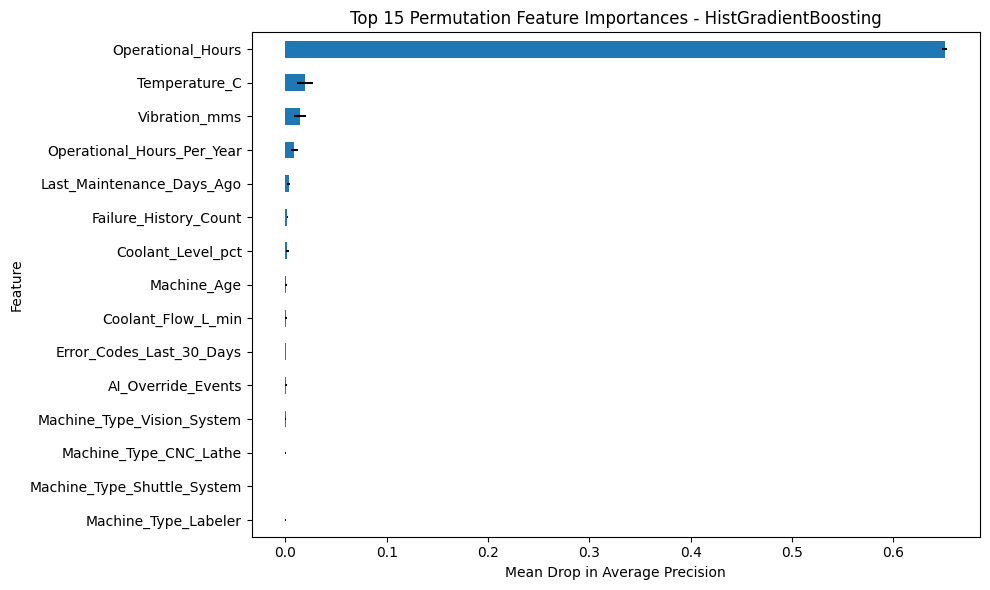

,Feature,Importance Mean,Importance Std
0,Operational_Hours,0.651,0.002
1,Temperature_C,0.019,0.008
2,Vibration_mms,0.014,0.006
18,Operational_Hours_Per_Year,0.009,0.003
7,Last_Maintenance_Days_Ago,0.003,0.002
9,Failure_History_Count,0.002,0.001
5,Coolant_Level_pct,0.002,0.001
17,Machine_Age,0.001,0.001
14,Coolant_Flow_L_min,0.001,0.001
11,Error_Codes_Last_30_Days,0.001,0.000


In [ ]:
# Select the model with the highest F1-Score
best_model_name = loaded_results_df.iloc[0]["Model"]
best_model = loaded_models[best_model_name]
best_model_results_path = RESULTS_PATH / safe_file_name(best_model_name)

importance_df = plot_permutation_importance(
    model_name=best_model_name,
    model=best_model,
    X=X_test,
    y=y_test,
    save_path=best_model_results_path / "permutation_feature_importance.png",
    top_n=15
)

importance_df.round(3).to_csv(
    best_model_results_path / "permutation_feature_importance.csv",
    index=False
)

display(importance_df.round(3))

## 10. End

The elapsed execution time is then calculated and displayed. This gives an indication of how long the complete pipeline took to run, including preprocessing, feature engineering, model training, validation, testing, plotting, and interpretability.

In [90]:
elapsed_time = time.time() - start_time
print(f">> [INFO] Elapsed Time: {elapsed_time:.3f} seconds | {elapsed_time / 60:.3f} minutes")

>> [INFO] Elapsed Time: 47.990 seconds | 0.800 minutes
